In [1]:
# ============================================================
# FULL KAGGLE NOTEBOOK CODE
# Fine-tuning XLM-RoBERTa on LABR + Sentiment140
# With strong EDA, cleaning, label engineering, metrics,
# plots, error analysis, and model saving
# ============================================================

# =========================
# 1) INSTALL
# =========================
import subprocess
import sys
import os

def pip_install(pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)

try:
    pip_install([
    "transformers==4.46.3",
    "accelerate==1.0.1",
    "datasets==2.21.0",
    "evaluate==0.4.3",
    "tokenizers==0.20.3",
    "scikit-learn",
    "matplotlib",
    "seaborn",
    "plotly",
    "wordcloud",
    "arabic-reshaper",
    "python-bidi"
])
except Exception as e:
    print("Package installation warning:", e)
    print("Continuing...")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 330.9/330.9 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 36.8 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
s3fs 2026.2.0 requires fsspec==2026.2.0, but you have fsspec 2024.6.1 which is incompatible.
tpot 1.1.0 requires dill>=0.3.9, but you have dill 0.3.8 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.


In [2]:
# =========================
# 2) IMPORTS + CONFIG
# =========================
import re
import json
import math
import random
import warnings
import collections
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    matthews_corrcoef
)

from datasets import Dataset, concatenate_datasets
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    pipeline
)

try:
    import evaluate
    EVALUATE_AVAILABLE = True
except Exception:
    EVALUATE_AVAILABLE = False

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

SEED = 42
MODEL_NAME = "xlm-roberta-base"
MAX_LENGTH = 128
MAX_TRAIN_EN = 200_000
MAX_TRAIN_AR = 200_000

LABR_PATH = "/kaggle/input/datasets/hositayeb/labr-and-sentiment-140-datasets/labr_train.csv"
S140_PATH = "/kaggle/input/datasets/hositayeb/labr-and-sentiment-140-datasets/training.1600000.processed.noemoticon.csv"

OUTPUT_DIR = "/kaggle/working/xlmr_labr_sent140_outputs"
MODEL_SAVE_DIR = "/kaggle/working/xlmr_multilingual_sentiment_best"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    try:
        from datasets import set_seed as hf_set_seed
        hf_set_seed(seed)
    except Exception:
        pass

set_seed(SEED)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("evaluate available:", EVALUATE_AVAILABLE)

2026-05-04 04:11:12.099376: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777867872.321164      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777867872.383383      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777867872.887686      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777867872.887724      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777867872.887727      23 computation_placer.cc:177] computation placer alr

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
evaluate available: True


In [3]:
# =========================
# 3) LOAD RAW DATA
# =========================
df_ar_raw = pd.read_csv(LABR_PATH)
print("LABR raw shape:", df_ar_raw.shape)
display(df_ar_raw.head())

colnames = ["target", "ids", "date", "flag", "user", "text"]
df_en_raw = pd.read_csv(S140_PATH, encoding="latin-1", names=colnames)
print("Sentiment140 raw shape:", df_en_raw.shape)
display(df_en_raw.head())

LABR raw shape: (11760, 2)


,text,label
0,هى رواية مملة لابعد الحدود مفيهاش اى حاجة تشد...,0
1,بدأت قِراءة الصفحات الأولى على نغمات فيفالدي ...,0
2,أول مرة اكتب انطباعي عن كتاب قبل ان أنتهي حتي...,0
3,خيالية جدًا . ماحبيتها الصراحة,0
4,"ولاني ما أتقن قراءة ما بين السطور , ما استسغت...",0


Sentiment140 raw shape: (1600000, 6)


,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


,dataset,rows,columns,missing_text
0,LABR_raw,11760,2,0
1,Sentiment140_raw,1600000,6,0


,raw_label,count
0,0,2352
1,1,2352
2,2,2352
3,3,2352
4,4,2352


,target,count
0,0,800000
1,4,800000


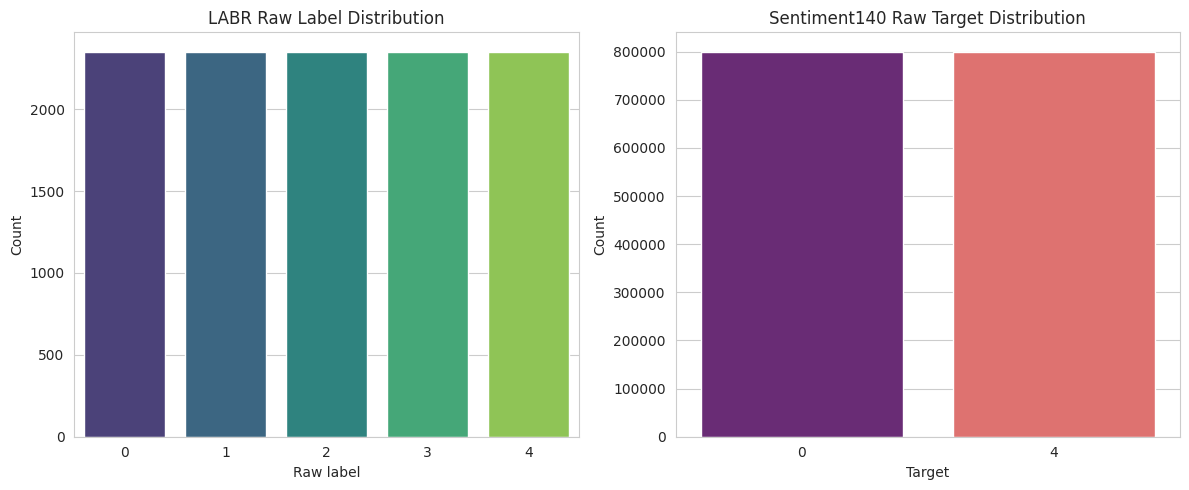

In [4]:
# =========================
# 4) RAW EDA
# =========================
eda_dataset_summary = pd.DataFrame([
    {
        "dataset": "LABR_raw",
        "rows": len(df_ar_raw),
        "columns": len(df_ar_raw.columns),
        "missing_text": df_ar_raw["text"].isna().sum() if "text" in df_ar_raw.columns else np.nan
    },
    {
        "dataset": "Sentiment140_raw",
        "rows": len(df_en_raw),
        "columns": len(df_en_raw.columns),
        "missing_text": df_en_raw["text"].isna().sum()
    }
])

display(eda_dataset_summary)
eda_dataset_summary.to_csv(f"{OUTPUT_DIR}/eda_dataset_summary.csv", index=False)

if "label" in df_ar_raw.columns:
    labr_raw_label_dist = df_ar_raw["label"].value_counts(dropna=False).sort_index().reset_index()
    labr_raw_label_dist.columns = ["raw_label", "count"]
    display(labr_raw_label_dist)
    labr_raw_label_dist.to_csv(f"{OUTPUT_DIR}/labr_raw_label_distribution.csv", index=False)

s140_raw_target_dist = df_en_raw["target"].value_counts(dropna=False).sort_index().reset_index()
s140_raw_target_dist.columns = ["target", "count"]
display(s140_raw_target_dist)
s140_raw_target_dist.to_csv(f"{OUTPUT_DIR}/sent140_raw_target_distribution.csv", index=False)

# --- RAW LABEL DISTRIBUTION PLOTS
plt.figure(figsize=(12, 5))
if "label" in df_ar_raw.columns:
    plt.subplot(1, 2, 1)
    sns.countplot(x="label", data=df_ar_raw, palette="viridis")
    plt.title("LABR Raw Label Distribution")
    plt.xlabel("Raw label")
    plt.ylabel("Count")

plt.subplot(1, 2, 2)
sns.countplot(x="target", data=df_en_raw, order=sorted(df_en_raw["target"].unique()), palette="magma")
plt.title("Sentiment140 Raw Target Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/raw_label_distribution.png", dpi=300)
plt.show()

In [5]:
# =========================
# 5) CLEANING + LABEL ENGINEERING
# =========================
_arabic_diacritics = re.compile(r"[\u0617-\u061A\u064B-\u0652]")
_tatweel = re.compile(r"\u0640")

def clean_arabic(t):
    t = str(t)
    t = re.sub(r"http\S+|www\.\S+", " ", t)
    t = _arabic_diacritics.sub("", t)
    t = _tatweel.sub("", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

def clean_en(t):
    t = str(t)
    t = re.sub(r"http\S+|www\.\S+", " ", t)
    t = re.sub(r"@\w+", " ", t)
    t = re.sub(r"\s+", " ", t).strip().lower()
    return t

def unify_labr_label(y):
    if pd.isna(y):
        return None
    y = int(y)
    if y in [0, 1]:
        return y
    if y == 2:
        return 0
    if y == 3:
        return None
    if y in [4, 5]:
        return 1
    return None

def char_len_stats(series):
    x = series.astype(str).map(len)
    return {
        "count": len(x),
        "mean_chars": x.mean(),
        "median_chars": x.median(),
        "p90_chars": x.quantile(0.90),
        "p95_chars": x.quantile(0.95),
        "max_chars": x.max()
    }

In [6]:
# =========================
# 6) PREPARE LABR
# =========================
df_ar = df_ar_raw[["text", "label"]].rename(columns={"label": "raw_label"}).copy()
df_ar["text_before"] = df_ar["text"].astype(str)
df_ar["char_len_before"] = df_ar["text_before"].map(len)
df_ar["text"] = df_ar["text_before"].map(clean_arabic)
df_ar["char_len_after"] = df_ar["text"].map(len)
df_ar["raw_label"] = pd.to_numeric(df_ar["raw_label"], errors="coerce")
df_ar["labels"] = df_ar["raw_label"].map(unify_labr_label)
df_ar["lang"] = "ar"
df_ar["source"] = "LABR"

labr_original_size = len(df_ar)
labr_neutral_invalid_removed = df_ar["labels"].isna().sum()

df_ar = df_ar.dropna(subset=["labels"]).copy()
df_ar["labels"] = df_ar["labels"].astype(int)

labr_empty_after_clean = (df_ar["text"].str.len() == 0).sum()
df_ar = df_ar[df_ar["text"].str.len() > 0].reset_index(drop=True)

print("LABR original:", labr_original_size)
print("LABR neutral/invalid removed:", labr_neutral_invalid_removed)
print("LABR empty-after-clean removed:", labr_empty_after_clean)
print("LABR final:", len(df_ar))
display(df_ar.head())
display(df_ar["labels"].value_counts().sort_index())

LABR original: 11760
LABR neutral/invalid removed: 2352
LABR empty-after-clean removed: 0
LABR final: 9408


,text,raw_label,text_before,char_len_before,char_len_after,labels,lang,source
0,هى رواية مملة لابعد الحدود مفيهاش اى حاجة تشد ...,0,هى رواية مملة لابعد الحدود مفيهاش اى حاجة تشد...,502,500,0,ar,LABR
1,بدأت قراءة الصفحات الأولى على نغمات فيفالدي ، ...,0,بدأت قِراءة الصفحات الأولى على نغمات فيفالدي ...,1065,1032,0,ar,LABR
2,أول مرة اكتب انطباعي عن كتاب قبل ان أنتهي حتي ...,0,أول مرة اكتب انطباعي عن كتاب قبل ان أنتهي حتي...,270,269,0,ar,LABR
3,خيالية جدا . ماحبيتها الصراحة,0,خيالية جدًا . ماحبيتها الصراحة,31,29,0,ar,LABR
4,"ولاني ما أتقن قراءة ما بين السطور , ما استسغته...",0,"ولاني ما أتقن قراءة ما بين السطور , ما استسغت...",155,154,0,ar,LABR


labels
0    4704
1    4704
Name: count, dtype: int64

In [7]:
# =========================
# 7) PREPARE SENTIMENT140
# =========================
df_en = df_en_raw[["text", "target"]].copy()
df_en = df_en[df_en["target"].isin([0, 4])].copy()
df_en["text_before"] = df_en["text"].astype(str)
df_en["char_len_before"] = df_en["text_before"].map(len)
df_en["text"] = df_en["text_before"].map(clean_en)
df_en["char_len_after"] = df_en["text"].map(len)
df_en["labels"] = df_en["target"].map({0: 0, 4: 1}).astype(int)
df_en["lang"] = "en"
df_en["source"] = "Sentiment140"

s140_original_size = len(df_en)
s140_empty_after_clean = (df_en["text"].str.len() == 0).sum()
df_en = df_en[df_en["text"].str.len() > 0].reset_index(drop=True)

print("Sentiment140 original filtered (0/4 only):", s140_original_size)
print("Sentiment140 empty-after-clean removed:", s140_empty_after_clean)
print("Sentiment140 final:", len(df_en))
display(df_en.head())
display(df_en["labels"].value_counts().sort_index())

Sentiment140 original filtered (0/4 only): 1600000
Sentiment140 empty-after-clean removed: 2815
Sentiment140 final: 1597185


,text,target,text_before,char_len_before,char_len_after,labels,lang,source
0,"- awww, that's a bummer. you shoulda got david...",0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",115,77,0,en,Sentiment140
1,is upset that he can't update his facebook by ...,0,is upset that he can't update his Facebook by ...,111,110,0,en,Sentiment140
2,i dived many times for the ball. managed to sa...,0,@Kenichan I dived many times for the ball. Man...,89,78,0,en,Sentiment140
3,my whole body feels itchy and like its on fire,0,my whole body feels itchy and like its on fire,47,46,0,en,Sentiment140
4,"no, it's not behaving at all. i'm mad. why am ...",0,"@nationwideclass no, it's not behaving at all....",111,93,0,en,Sentiment140


labels
0    798497
1    798688
Name: count, dtype: int64

In [8]:
# =========================
# 8) POST-CLEAN SUMMARY
# =========================
post_clean_summary = pd.DataFrame([
    {
        "dataset": "LABR",
        "original_size": labr_original_size,
        "final_size": len(df_ar),
        "removed_neutral_invalid": labr_neutral_invalid_removed,
        "removed_empty_after_clean": labr_empty_after_clean,
        "drop_ratio_percent": round(100 * (labr_original_size - len(df_ar)) / labr_original_size, 2),
        "negative": int((df_ar["labels"] == 0).sum()),
        "positive": int((df_ar["labels"] == 1).sum()),
        "language": "Arabic",
        "labels_used": "binary (0=negative,1=positive)"
    },
    {
        "dataset": "Sentiment140",
        "original_size": len(df_en_raw),
        "final_size": len(df_en),
        "removed_neutral_invalid": 0,
        "removed_empty_after_clean": s140_empty_after_clean,
        "drop_ratio_percent": round(100 * (len(df_en_raw) - len(df_en)) / len(df_en_raw), 2),
        "negative": int((df_en["labels"] == 0).sum()),
        "positive": int((df_en["labels"] == 1).sum()),
        "language": "English",
        "labels_used": "binary (0=negative,1=positive)"
    }
])

display(post_clean_summary)
post_clean_summary.to_csv(f"{OUTPUT_DIR}/post_clean_summary.csv", index=False)

,dataset,original_size,final_size,removed_neutral_invalid,removed_empty_after_clean,drop_ratio_percent,negative,positive,language,labels_used
0,LABR,11760,9408,2352,0,20.00,4704,4704,Arabic,"binary (0=negative,1=positive)"
1,Sentiment140,1600000,1597185,0,2815,0.18,798497,798688,English,"binary (0=negative,1=positive)"


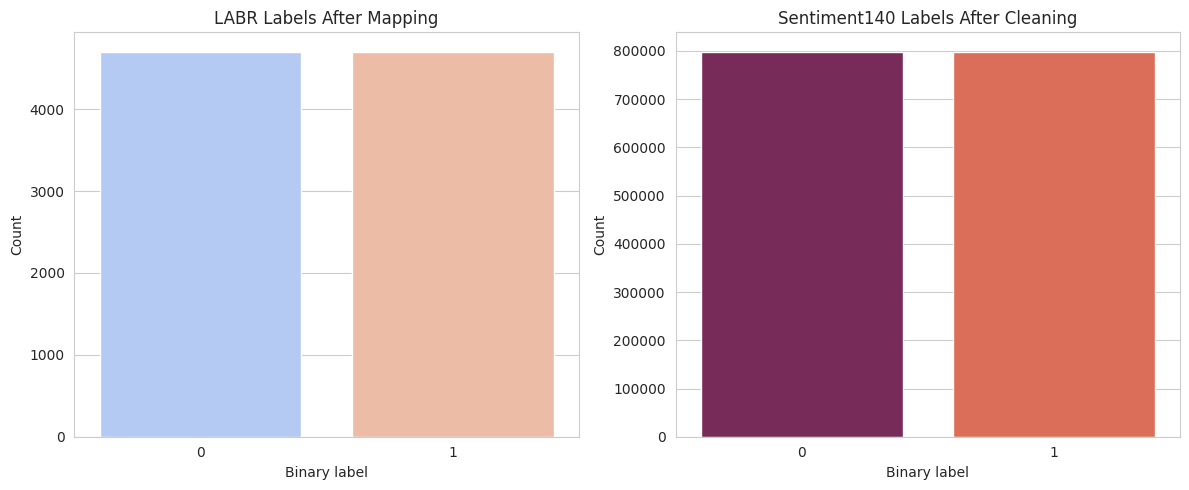

In [9]:
# =========================
# 9) LABEL DISTRIBUTION BEFORE/AFTER MAPPING
# =========================
if "label" in df_ar_raw.columns:
    labr_before_after = pd.DataFrame({
        "stage": ["raw"] * len(df_ar_raw["label"].value_counts(dropna=False)) + ["mapped_binary"] * df_ar["labels"].nunique(),
        "label": list(df_ar_raw["label"].value_counts(dropna=False).sort_index().index.astype(str)) + list(df_ar["labels"].value_counts().sort_index().index.astype(str)),
        "count": list(df_ar_raw["label"].value_counts(dropna=False).sort_index().values) + list(df_ar["labels"].value_counts().sort_index().values)
    })
    labr_before_after.to_csv(f"{OUTPUT_DIR}/labr_before_after_label_distribution.csv", index=False)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x="labels", data=df_ar, palette="coolwarm")
plt.title("LABR Labels After Mapping")
plt.xlabel("Binary label")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
sns.countplot(x="labels", data=df_en, palette="rocket")
plt.title("Sentiment140 Labels After Cleaning")
plt.xlabel("Binary label")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/post_clean_label_distribution.png", dpi=300)
plt.show()

,dataset,count,mean_chars,median_chars,p90_chars,p95_chars,max_chars
0,LABR_before_clean,9408,322.593644,164.0,719.0,1121.0,14773
1,LABR_after_clean,9408,319.369154,162.0,715.3,1115.0,14607
2,Sentiment140_before_clean,1597185,74.195460,69.0,130.0,136.0,374
3,Sentiment140_after_clean,1597185,65.831584,61.0,120.0,128.0,360


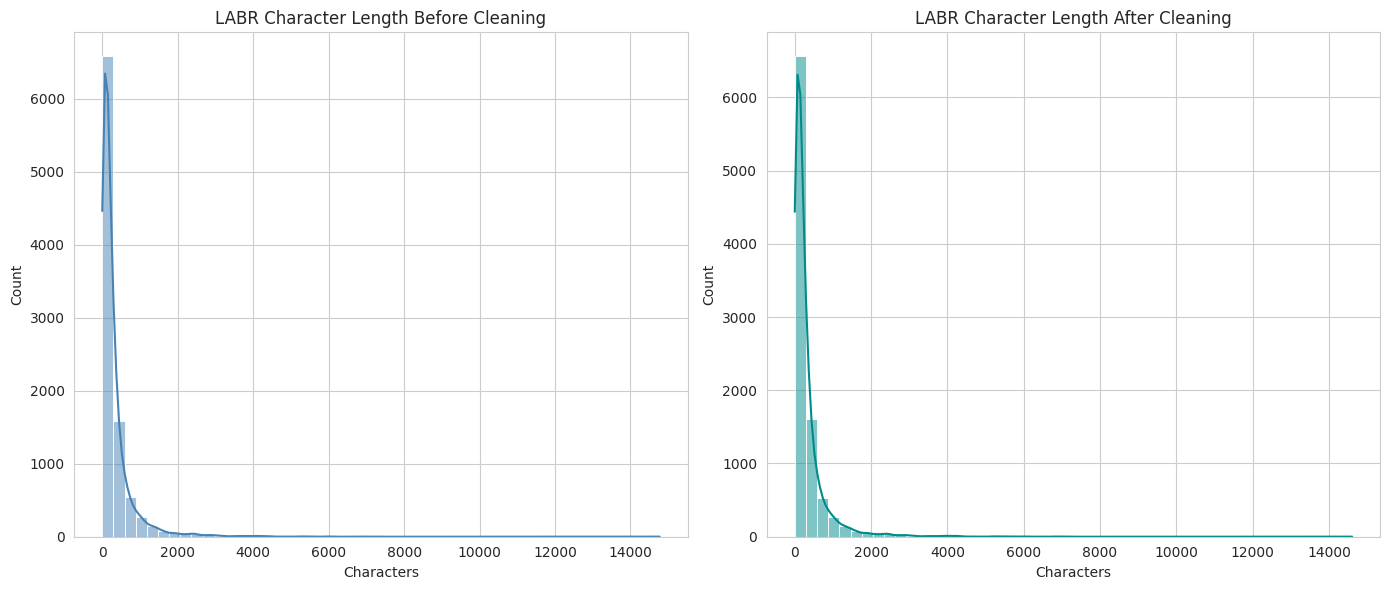

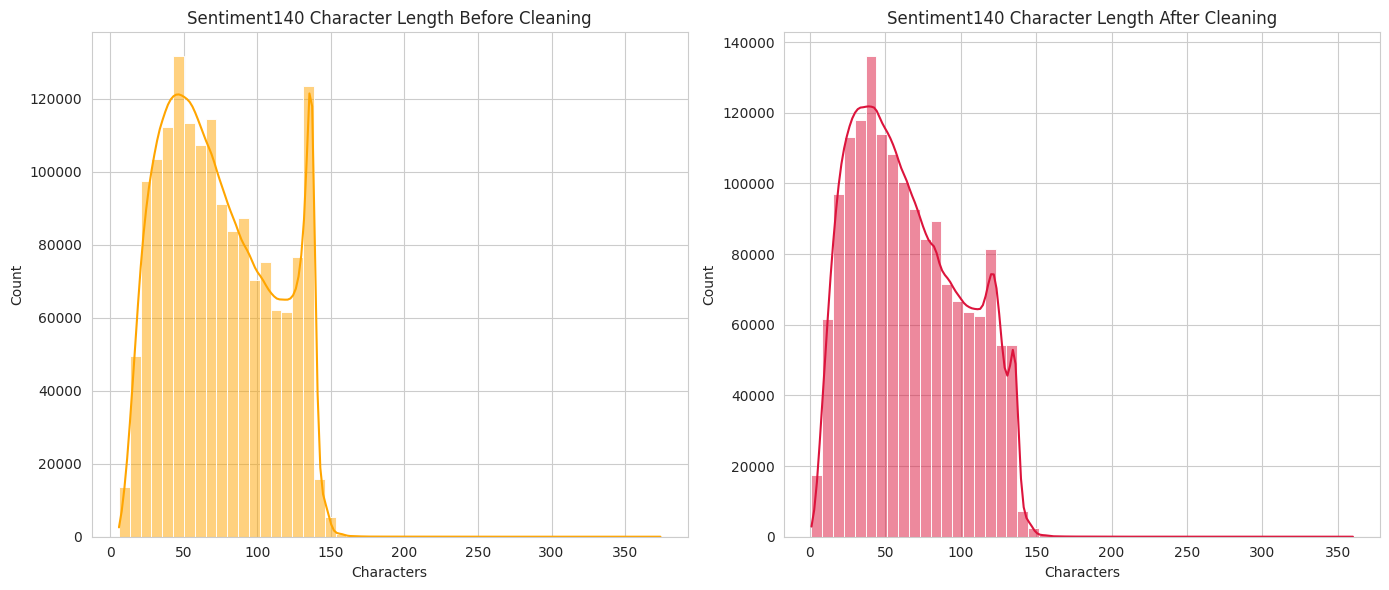

In [10]:
# =========================
# 10) TEXT LENGTH EDA BEFORE / AFTER CLEANING
# =========================
text_length_summary = pd.DataFrame([
    {"dataset": "LABR_before_clean", **char_len_stats(df_ar["text_before"])},
    {"dataset": "LABR_after_clean", **char_len_stats(df_ar["text"])},
    {"dataset": "Sentiment140_before_clean", **char_len_stats(df_en["text_before"])},
    {"dataset": "Sentiment140_after_clean", **char_len_stats(df_en["text"])}
])

display(text_length_summary)
text_length_summary.to_csv(f"{OUTPUT_DIR}/text_length_summary_chars.csv", index=False)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(df_ar["char_len_before"], bins=50, color="steelblue", kde=True)
plt.title("LABR Character Length Before Cleaning")
plt.xlabel("Characters")

plt.subplot(1, 2, 2)
sns.histplot(df_ar["char_len_after"], bins=50, color="darkcyan", kde=True)
plt.title("LABR Character Length After Cleaning")
plt.xlabel("Characters")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/labr_char_length_before_after.png", dpi=300)
plt.show()

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(df_en["char_len_before"], bins=50, color="orange", kde=True)
plt.title("Sentiment140 Character Length Before Cleaning")
plt.xlabel("Characters")

plt.subplot(1, 2, 2)
sns.histplot(df_en["char_len_after"], bins=50, color="crimson", kde=True)
plt.title("Sentiment140 Character Length After Cleaning")
plt.xlabel("Characters")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/sent140_char_length_before_after.png", dpi=300)
plt.show()

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

,dataset,count,mean_tokens,median_tokens,p90_tokens,p95_tokens,p99_tokens,max_tokens_after_cap_512,pct_le_max_length
0,LABR,9408.0,94.567071,54.0,227.3,359.0,512.0,512.0,78.64
1,Sentiment140,1597185.0,20.215406,19.0,35.0,38.0,44.0,360.0,99.98


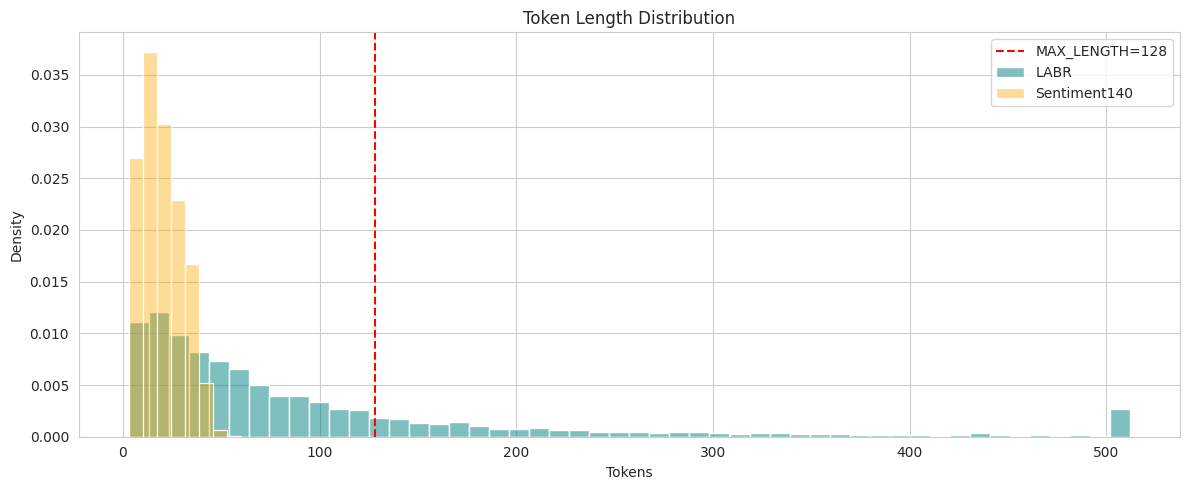

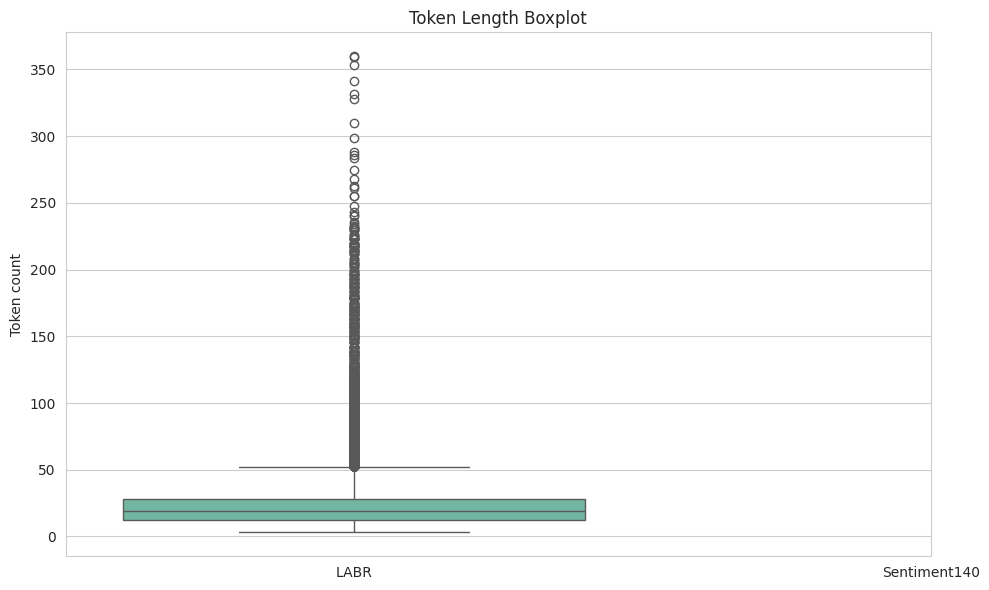

In [11]:
# =========================
# 11) TOKENIZER + TOKEN LENGTH EDA
# =========================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def safe_token_len(text):
    return len(tokenizer(str(text), truncation=True, max_length=512)["input_ids"])

def token_length_stats(df, text_col="text"):
    lengths = df[text_col].astype(str).apply(safe_token_len)
    stats = pd.Series({
        "count": len(lengths),
        "mean_tokens": lengths.mean(),
        "median_tokens": lengths.median(),
        "p90_tokens": lengths.quantile(0.90),
        "p95_tokens": lengths.quantile(0.95),
        "p99_tokens": lengths.quantile(0.99),
        "max_tokens_after_cap_512": lengths.max(),
        "pct_le_max_length": round((lengths <= MAX_LENGTH).mean() * 100, 2)
    })
    return stats, lengths

stats_ar, lengths_ar = token_length_stats(df_ar)
stats_en, lengths_en = token_length_stats(df_en)

token_length_summary = pd.DataFrame([
    {"dataset": "LABR", **stats_ar.to_dict()},
    {"dataset": "Sentiment140", **stats_en.to_dict()}
])

display(token_length_summary)
token_length_summary.to_csv(f"{OUTPUT_DIR}/token_length_stats.csv", index=False)

plt.figure(figsize=(12, 5))
sns.histplot(lengths_ar, label="LABR", color="teal", bins=50, stat="density", alpha=0.5)
sns.histplot(lengths_en, label="Sentiment140", color="orange", bins=50, stat="density", alpha=0.4)
plt.axvline(MAX_LENGTH, color="red", linestyle="--", label=f"MAX_LENGTH={MAX_LENGTH}")
plt.legend()
plt.title("Token Length Distribution")
plt.xlabel("Tokens")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/token_length_distribution.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=[lengths_ar, lengths_en], palette="Set2")
plt.xticks([0, 1], ["LABR", "Sentiment140"])
plt.ylabel("Token count")
plt.title("Token Length Boxplot")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/token_length_boxplot.png", dpi=300)
plt.show()

In [12]:
# =========================
# 12) RANDOM CLEANING EXAMPLES
# =========================
sample_ar = df_ar[["text_before", "text", "labels"]].sample(5, random_state=SEED)
sample_en = df_en[["text_before", "text", "labels"]].sample(5, random_state=SEED)

display(sample_ar)
display(sample_en)

sample_ar.to_csv(f"{OUTPUT_DIR}/sample_cleaning_ar.csv", index=False)
sample_en.to_csv(f"{OUTPUT_DIR}/sample_cleaning_en.csv", index=False)

,text_before,text,labels
6642,من 3 إلى 4 نجوم . الرواية رائعة لقيمتها التار...,من 3 إلى 4 نجوم . الرواية رائعة لقيمتها التاري...,0
592,"العمل كبناء روائي , ضعيف جدًا . و مقومات الرو...","العمل كبناء روائي , ضعيف جدا . و مقومات الرواي...",0
9156,وخاصة الفصل الخاص بالنساء قرأته أكثر من مرة ف...,وخاصة الفصل الخاص بالنساء قرأته أكثر من مرة في...,1
6973,اللهم صل وسلم وبارك على اشرف الخلق نبى الله ا...,اللهم صل وسلم وبارك على اشرف الخلق نبى الله ال...,0
4296,"حلو في اﻷول, بعد كده بيبدأ الحشو وشوية كلام م...","حلو في اﻷول, بعد كده بيبدأ الحشو وشوية كلام مل...",1


,text_before,text,labels
1002238,@JanetcBaby i want a tan too!! i'll juz have t...,i want a tan too!! i'll juz have to wait nxt m...,1
28474,Ugh not excited about flying back to San diego...,ugh not excited about flying back to san diego...,0
1500141,Watching Mulan TWO with the little sister and ...,watching mulan two with the little sister and ...,1
1045828,In bed thank you guys for coming to my lil bd...,in bed thank you guys for coming to my lil bda...,1
63077,@stephenfry They didn't lose it on one days pe...,"they didn't lose it on one days performance, i...",0


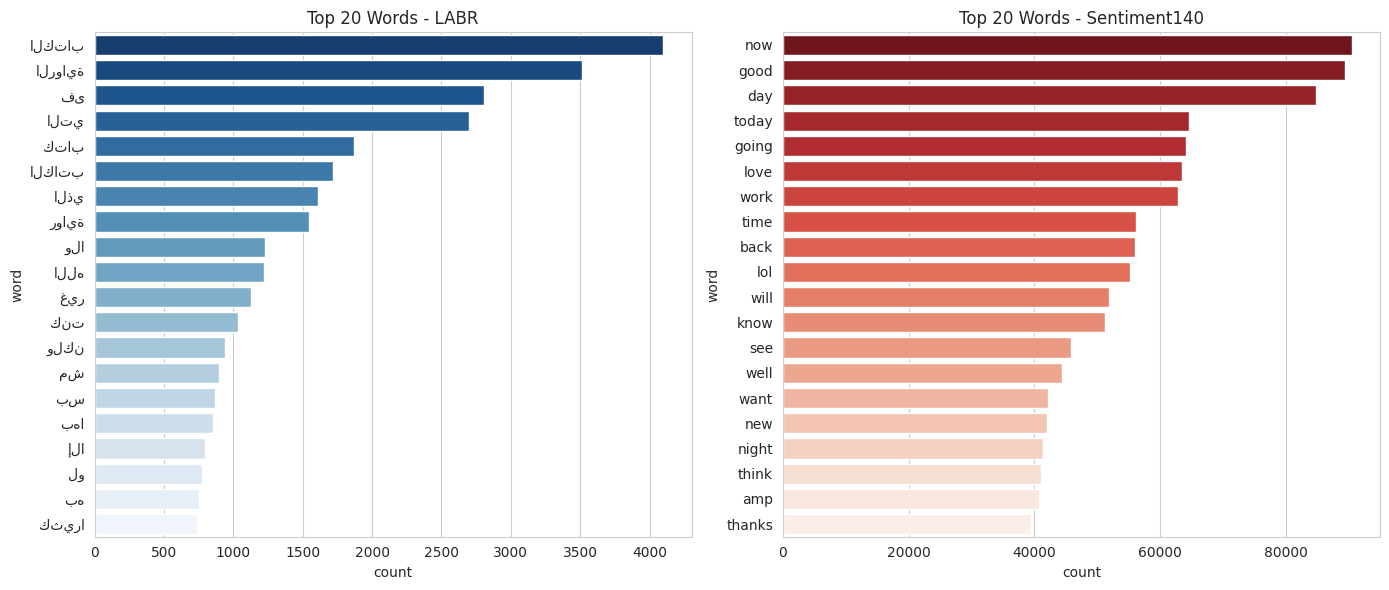

No suitable Arabic font found locally. Downloading Noto Naskh Arabic...
Arabic font path used: /kaggle/working/fonts/NotoNaskhArabic-Regular.ttf


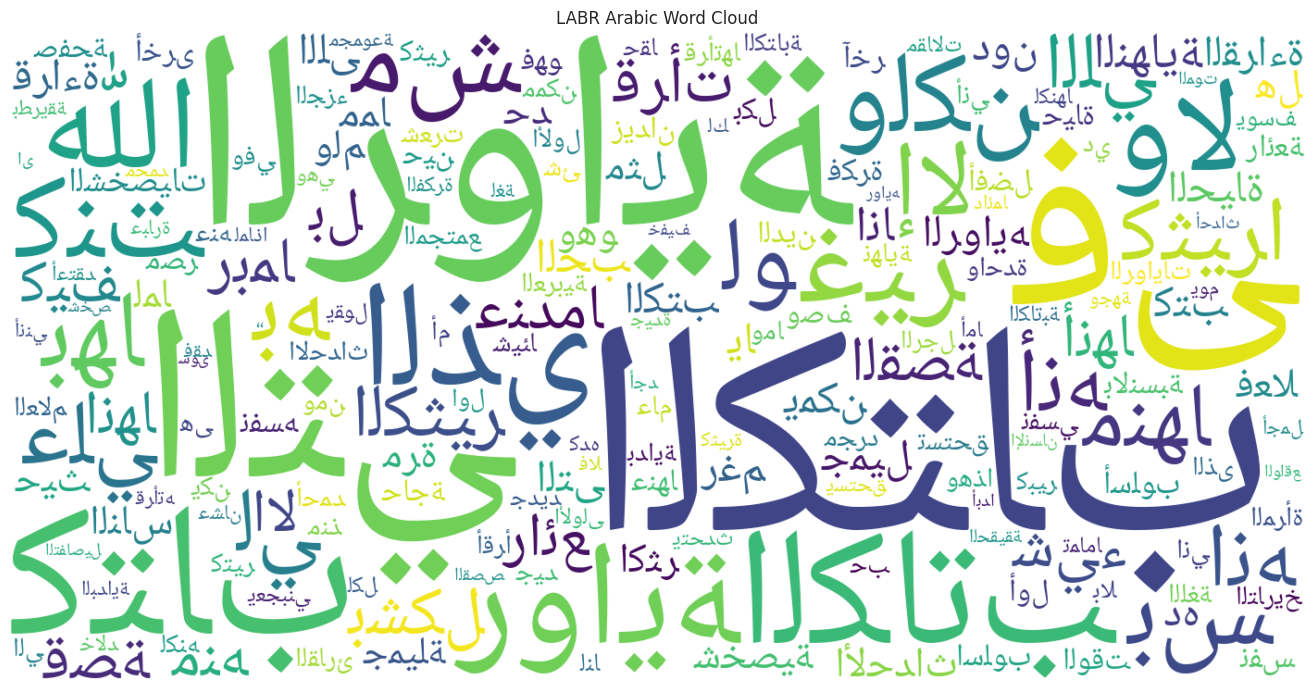

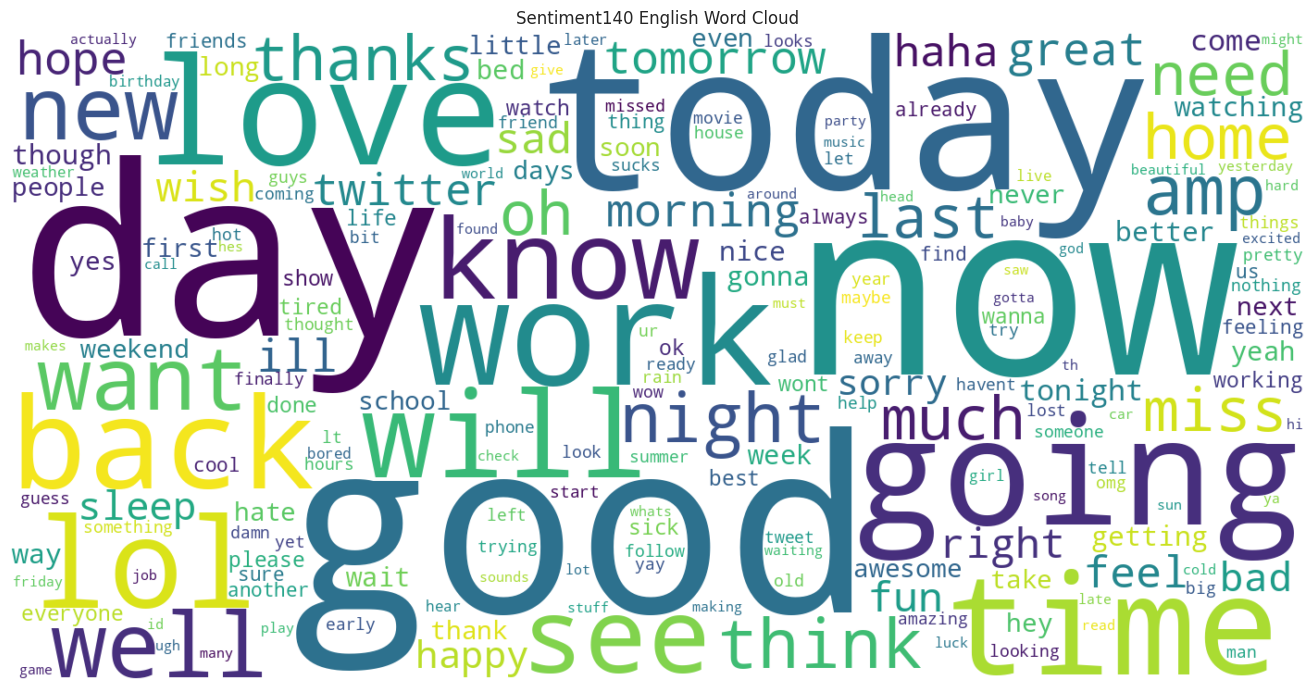

In [13]:
# =========================
# 13) TOP WORDS + WORD CLOUDS
# =========================
import os
import glob
import re
import urllib.request
import arabic_reshaper
from bidi.algorithm import get_display
from wordcloud import WordCloud, STOPWORDS
from collections import Counter

# ---------- Simple stopwords ----------
AR_STOPWORDS = {
    "في","من","على","الى","إلى","عن","ما","ماذا","هذا","هذه","ذلك","تلك","هناك",
    "هنا","هو","هي","هم","هن","أنا","نحن","أنت","انتم","أنتم","انت","ان","إن",
    "أن","او","أو","ثم","كما","لكن","لأن","لان","لقد","قد","كان","كانت","يكون",
    "تكون","تم","مع","كل","بعض","أي","اي","أحد","واحد","إحدى","اذا","إذا","بعد",
    "قبل","بين","حتى","أمام","خلال","حول","عند","عليه","عليها","عليهم","عليهن",
    "له","لها","لهم","لهن","فيه","فيها","فيهم","فيهن","تمت","جدا","جداً","فقط",
    "أيضا","أيضاً","لا","لم","لن","مازال","ليس","ليست","كما","بأن","بسبب","ضمن",
    "أكثر","اقل","أقل","كلها","كله","و","ف","ب","ل","ال","الى","إلي"
}

EN_STOPWORDS = set(STOPWORDS).union({
    "im","ive","youre","theyre","dont","didnt","doesnt","cant","couldnt","wouldnt",
    "isnt","arent","wasnt","werent","thats","theres","here","also","still","really",
    "one","two","get","got","go","goes","went","say","says","said","make","made"
})

# ---------- Token cleaning ----------
def clean_ar_token(token):
    token = str(token).strip()
    token = re.sub(r"[^\u0600-\u06FF]+", "", token)
    return token

def clean_en_token(token):
    token = str(token).strip().lower()
    token = re.sub(r"[^a-z]+", "", token)
    return token

def get_top_n_words_ar(corpus, n=20, min_len=2):
    tokens = []
    for text in corpus.astype(str):
        for tok in text.split():
            tok = clean_ar_token(tok)
            if tok and tok not in AR_STOPWORDS and len(tok) >= min_len:
                tokens.append(tok)
    return Counter(tokens).most_common(n)

def get_top_n_words_en(corpus, n=20, min_len=2):
    tokens = []
    for text in corpus.astype(str):
        for tok in text.split():
            tok = clean_en_token(tok)
            if tok and tok not in EN_STOPWORDS and len(tok) >= min_len:
                tokens.append(tok)
    return Counter(tokens).most_common(n)

# ---------- Top words ----------
top_words_ar = pd.DataFrame(get_top_n_words_ar(df_ar["text"], 20), columns=["word", "count"])
top_words_en = pd.DataFrame(get_top_n_words_en(df_en["text"], 20), columns=["word", "count"])

top_words_ar.to_csv(f"{OUTPUT_DIR}/top_words_ar.csv", index=False)
top_words_en.to_csv(f"{OUTPUT_DIR}/top_words_en.csv", index=False)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.barplot(data=top_words_ar, x="count", y="word", palette="Blues_r")
plt.title("Top 20 Words - LABR")

plt.subplot(1, 2, 2)
sns.barplot(data=top_words_en, x="count", y="word", palette="Reds_r")
plt.title("Top 20 Words - Sentiment140")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/top_words_barplots.png", dpi=300)
plt.show()

# ---------- Arabic font handling ----------
FONT_DIR = "/kaggle/working/fonts"
os.makedirs(FONT_DIR, exist_ok=True)

DOWNLOADED_ARABIC_FONT = os.path.join(FONT_DIR, "NotoNaskhArabic-Regular.ttf")

def find_local_arabic_font():
    preferred_fonts = [
        "/usr/share/fonts/truetype/noto/NotoNaskhArabic-Regular.ttf",
        "/usr/share/fonts/truetype/noto/NotoSansArabic-Regular.ttf",
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
    ]
    for fp in preferred_fonts:
        if os.path.exists(fp):
            return fp

    all_fonts = glob.glob("/usr/share/fonts/**/*.ttf", recursive=True)
    priority_keywords = [
        "notonaskharabic",
        "notosansarabic",
        "amiri",
        "scheherazade",
        "dejavusans"
    ]

    for keyword in priority_keywords:
        for fp in all_fonts:
            name = os.path.basename(fp).lower().replace("-", "").replace("_", "")
            if keyword in name:
                return fp
    return None

ARABIC_FONT_PATH = find_local_arabic_font()

if ARABIC_FONT_PATH is None:
    print("No suitable Arabic font found locally. Downloading Noto Naskh Arabic...")
    font_url = "https://raw.githubusercontent.com/notofonts/notofonts.github.io/noto-monthly-release-2025.05.01/fonts/NotoNaskhArabic/hinted/ttf/NotoNaskhArabic-Regular.ttf"
    urllib.request.urlretrieve(font_url, DOWNLOADED_ARABIC_FONT)
    ARABIC_FONT_PATH = DOWNLOADED_ARABIC_FONT

print("Arabic font path used:", ARABIC_FONT_PATH)

# ---------- Frequency builders ----------
def build_arabic_frequencies(text_series, min_len=2, max_words=300):
    tokens = []
    for text in text_series.astype(str):
        for tok in text.split():
            tok = clean_ar_token(tok)
            if tok and tok not in AR_STOPWORDS and len(tok) >= min_len:
                tokens.append(tok)

    freq = Counter(tokens).most_common(max_words)

    reshaped_freq = {}
    for word, count in freq:
        reshaped_word = get_display(arabic_reshaper.reshape(word))
        reshaped_freq[reshaped_word] = count

    return reshaped_freq

def build_english_frequencies(text_series, min_len=2, max_words=300):
    tokens = []
    for text in text_series.astype(str):
        for tok in text.split():
            tok = clean_en_token(tok)
            if tok and tok not in EN_STOPWORDS and len(tok) >= min_len:
                tokens.append(tok)
    return dict(Counter(tokens).most_common(max_words))

# ---------- Word cloud functions ----------
def make_wordcloud_ar(text_series, title, out_path, background="white"):
    frequencies = build_arabic_frequencies(text_series, min_len=2, max_words=300)

    if len(frequencies) == 0:
        print(f"Skipping empty Arabic wordcloud: {title}")
        return

    wc = WordCloud(
        font_path=ARABIC_FONT_PATH,
        width=1400,
        height=700,
        background_color=background,
        collocations=False,
        prefer_horizontal=1.0
    ).generate_from_frequencies(frequencies)

    plt.figure(figsize=(14, 7))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

def make_wordcloud_en(text_series, title, out_path, background="white"):
    frequencies = build_english_frequencies(text_series, min_len=2, max_words=300)

    if len(frequencies) == 0:
        print(f"Skipping empty English wordcloud: {title}")
        return

    wc = WordCloud(
        width=1400,
        height=700,
        background_color=background,
        collocations=False,
        prefer_horizontal=1.0
    ).generate_from_frequencies(frequencies)

    plt.figure(figsize=(14, 7))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

# ---------- Generate word clouds ----------
make_wordcloud_ar(df_ar["text"], "LABR Arabic Word Cloud", f"{OUTPUT_DIR}/wordcloud_ar.png")
make_wordcloud_en(df_en["text"], "Sentiment140 English Word Cloud", f"{OUTPUT_DIR}/wordcloud_en.png")

In [14]:
# =========================
# 14) SPLIT FUNCTION
# =========================
def split_df(df, test_size=0.1, val_size=0.1, seed=SEED):
    train_df, test_df = train_test_split(
        df,
        test_size=test_size,
        random_state=seed,
        stratify=df["labels"]
    )
    val_rel = val_size / (1 - test_size)
    train_df, val_df = train_test_split(
        train_df,
        test_size=val_rel,
        random_state=seed,
        stratify=train_df["labels"]
    )
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)

,dataset,split,rows,negative,positive
0,LABR,train,7526,3763,3763
1,LABR,validation,941,470,471
2,LABR,test,941,471,470
3,Sentiment140,train,200000,100347,99653
4,Sentiment140,validation,159719,79850,79869
5,Sentiment140,test,159719,79850,79869


,split,lang_en,lang_ar
0,train,200000,7526
1,validation,159719,941
2,test,159719,941


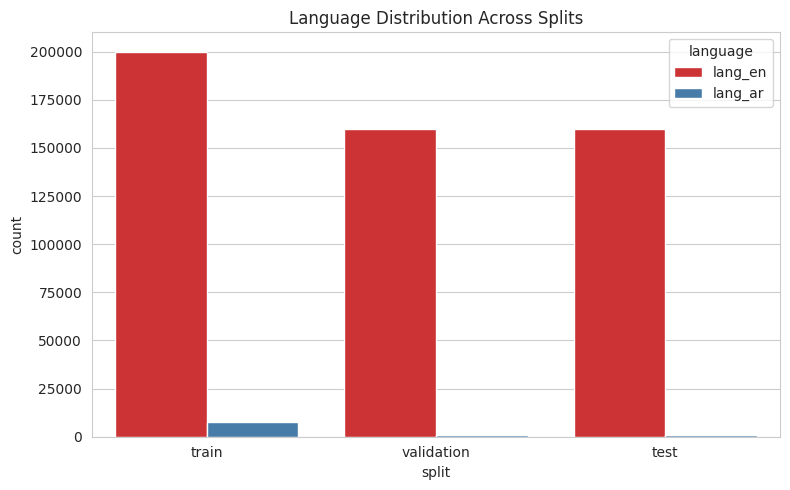

In [15]:
# =========================
# 15) SPLIT DATASETS
# =========================
train_ar, val_ar, test_ar = split_df(df_ar)
train_en, val_en, test_en = split_df(df_en)

train_ar = train_ar.sample(n=min(len(train_ar), MAX_TRAIN_AR), random_state=SEED).reset_index(drop=True)
train_en = train_en.sample(n=min(len(train_en), MAX_TRAIN_EN), random_state=SEED).reset_index(drop=True)

def split_summary(name, train_df, val_df, test_df):
    rows = []
    for split_name, d in [("train", train_df), ("validation", val_df), ("test", test_df)]:
        rows.append({
            "dataset": name,
            "split": split_name,
            "rows": len(d),
            "negative": int((d["labels"] == 0).sum()),
            "positive": int((d["labels"] == 1).sum())
        })
    return rows

split_df_summary = pd.DataFrame(
    split_summary("LABR", train_ar, val_ar, test_ar) +
    split_summary("Sentiment140", train_en, val_en, test_en)
)

display(split_df_summary)
split_df_summary.to_csv(f"{OUTPUT_DIR}/split_summary.csv", index=False)

# --- language/source distribution after split
split_lang_distribution = pd.DataFrame([
    {"split": "train", "lang_en": len(train_en), "lang_ar": len(train_ar)},
    {"split": "validation", "lang_en": len(val_en), "lang_ar": len(val_ar)},
    {"split": "test", "lang_en": len(test_en), "lang_ar": len(test_ar)}
])
display(split_lang_distribution)
split_lang_distribution.to_csv(f"{OUTPUT_DIR}/split_language_distribution.csv", index=False)

plt.figure(figsize=(8, 5))
split_lang_distribution_plot = split_lang_distribution.melt(id_vars="split", var_name="language", value_name="count")
sns.barplot(data=split_lang_distribution_plot, x="split", y="count", hue="language", palette="Set1")
plt.title("Language Distribution Across Splits")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/split_language_distribution.png", dpi=300)
plt.show()

In [16]:
# =========================
# 16) MERGE TO HF DATASETS
# =========================
def to_hf(df):
    return Dataset.from_pandas(df[["text", "labels", "lang", "source"]].reset_index(drop=True))

train_ds = concatenate_datasets([to_hf(train_en), to_hf(train_ar)]).shuffle(seed=SEED)
val_ds   = concatenate_datasets([to_hf(val_en), to_hf(val_ar)]).shuffle(seed=SEED)
test_ds  = concatenate_datasets([to_hf(test_en), to_hf(test_ar)]).shuffle(seed=SEED)

print(train_ds)
print(val_ds)
print(test_ds)

Dataset({
    features: ['text', 'labels', 'lang', 'source'],
    num_rows: 207526
})
Dataset({
    features: ['text', 'labels', 'lang', 'source'],
    num_rows: 160660
})
Dataset({
    features: ['text', 'labels', 'lang', 'source'],
    num_rows: 160660
})


In [17]:
# =========================
# 17) TOKENIZATION
# =========================
def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

remove_cols = [c for c in train_ds.column_names if c not in ["labels"]]

train_tok = train_ds.map(tokenize_fn, batched=True, remove_columns=remove_cols)
val_tok   = val_ds.map(tokenize_fn, batched=True, remove_columns=remove_cols)
test_tok  = test_ds.map(tokenize_fn, batched=True, remove_columns=remove_cols)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map:   0%|          | 0/207526 [00:00<?, ? examples/s]

Map:   0%|          | 0/160660 [00:00<?, ? examples/s]

Map:   0%|          | 0/160660 [00:00<?, ? examples/s]

In [18]:
# =========================
# 18) METRICS
# =========================
if EVALUATE_AVAILABLE:
    acc_metric = evaluate.load("accuracy")
    f1_metric = evaluate.load("f1")
    precision_metric = evaluate.load("precision")
    recall_metric = evaluate.load("recall")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    preds = np.argmax(logits, axis=-1)

    if EVALUATE_AVAILABLE:
        acc = acc_metric.compute(predictions=preds, references=labels)["accuracy"]
        f1_weighted = f1_metric.compute(predictions=preds, references=labels, average="weighted")["f1"]
        f1_macro = f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"]
        precision_macro = precision_metric.compute(predictions=preds, references=labels, average="macro")["precision"]
        recall_macro = recall_metric.compute(predictions=preds, references=labels, average="macro")["recall"]
    else:
        precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
        _, _, f1_weighted, _ = precision_recall_fscore_support(labels, preds, average="weighted", zero_division=0)
        acc = accuracy_score(labels, preds)

    roc_auc = roc_auc_score(labels, probs)
    pr_auc = average_precision_score(labels, probs)
    mcc = matthews_corrcoef(labels, preds)

    return {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "mcc": mcc
    }

In [19]:
# =========================
# 19) MODEL
# =========================
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

# =========================
# 20) TRAINING ARGUMENTS
# =========================
training_args = TrainingArguments(
    output_dir=f"{OUTPUT_DIR}/checkpoints",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    report_to="none",
    logging_steps=100,
    save_total_limit=2,
    seed=SEED
)

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [20]:
# =========================
# 21) TRAINER
# =========================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)

In [21]:
# =========================
# 22) TRAIN
# =========================
train_result = trainer.train()
trainer.save_model(MODEL_SAVE_DIR)
tokenizer.save_pretrained(MODEL_SAVE_DIR)

with open(f"{OUTPUT_DIR}/train_result.json", "w") as f:
    json.dump(train_result.metrics, f, indent=2)

print("Model saved to:", MODEL_SAVE_DIR)

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted,Roc Auc,Pr Auc,Mcc
1,0.347700,0.350336,0.847336,0.847399,0.847335,0.847329,0.847329,0.925956,0.926070,0.694734
2,0.327500,0.351543,0.854712,0.855139,0.854714,0.854669,0.854668,0.932114,0.932428,0.709853
3,0.273300,0.364604,0.855913,0.855919,0.855913,0.855913,0.855913,0.932378,0.932359,0.711832


Model saved to: /kaggle/working/xlmr_multilingual_sentiment_best


In [22]:
# =========================
# 23) TRAINING LOG HISTORY
# =========================
log_history = pd.DataFrame(trainer.state.log_history)
display(log_history.head())
log_history.to_csv(f"{OUTPUT_DIR}/training_log_history.csv", index=False)

best_eval_rows = log_history.dropna(subset=["eval_loss"], how="all").copy()
if not best_eval_rows.empty:
    best_eval_rows.to_csv(f"{OUTPUT_DIR}/best_validation_metrics_per_epoch.csv", index=False)

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_precision_macro,eval_recall_macro,eval_f1_macro,...,eval_pr_auc,eval_mcc,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.6237,7.962825e+05,0.000020,0.015418,100,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.5396,1.011977e+06,0.000020,0.030836,200,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.5001,6.050942e+05,0.000020,0.046253,300,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.4625,3.621567e+05,0.000020,0.061671,400,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.4436,7.258295e+05,0.000019,0.077089,500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


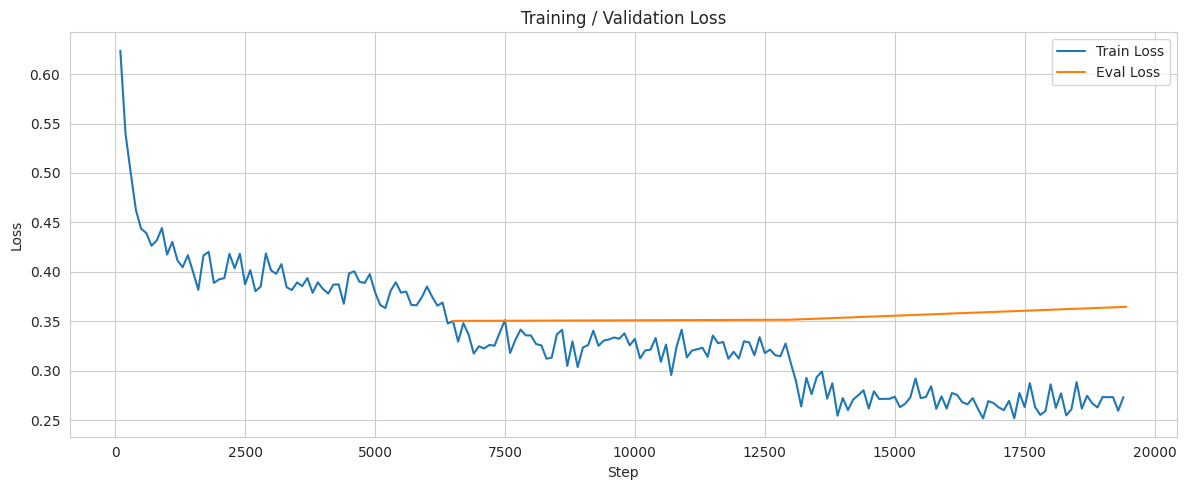

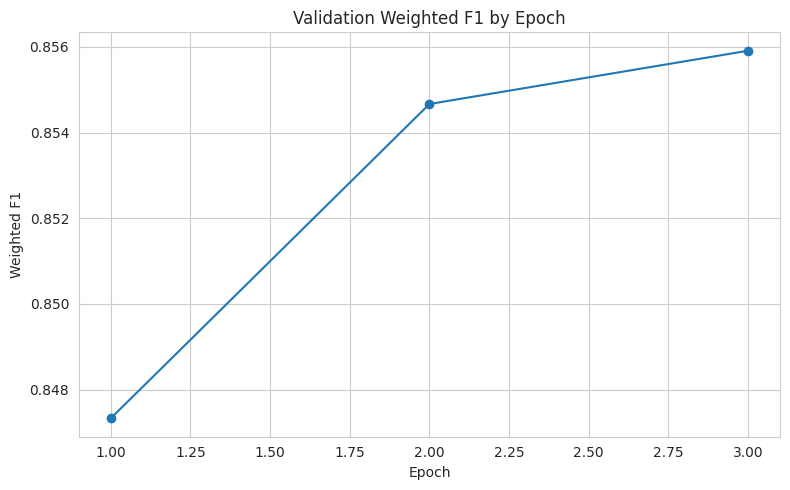

In [23]:
# =========================
# 24) LOSS + F1 CURVES
# =========================
if not log_history.empty:
    plt.figure(figsize=(12, 5))
    if "loss" in log_history.columns:
        train_logs = log_history.dropna(subset=["loss"])
        plt.plot(train_logs["step"], train_logs["loss"], label="Train Loss")
    if "eval_loss" in log_history.columns:
        eval_logs = log_history.dropna(subset=["eval_loss"])
        plt.plot(eval_logs["step"], eval_logs["eval_loss"], label="Eval Loss")
    plt.legend()
    plt.title("Training / Validation Loss")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/loss_curve.png", dpi=300)
    plt.show()

    if "eval_f1_weighted" in log_history.columns:
        eval_logs = log_history.dropna(subset=["eval_f1_weighted"])
        plt.figure(figsize=(8, 5))
        plt.plot(eval_logs["epoch"], eval_logs["eval_f1_weighted"], marker="o")
        plt.title("Validation Weighted F1 by Epoch")
        plt.xlabel("Epoch")
        plt.ylabel("Weighted F1")
        plt.tight_layout()
        plt.savefig(f"{OUTPUT_DIR}/val_f1_curve.png", dpi=300)
        plt.show()

In [24]:
# =========================
# 25) GLOBAL TEST EVALUATION
# =========================
pred_out = trainer.predict(test_tok)
logits = pred_out.predictions
y_true = pred_out.label_ids
y_pred = np.argmax(logits, axis=-1)
y_prob = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]

precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0
)
_, _, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0
)

global_metrics = {
    "accuracy": accuracy_score(y_true, y_pred),
    "precision_macro": precision_macro,
    "recall_macro": recall_macro,
    "f1_macro": f1_macro,
    "f1_weighted": f1_weighted,
    "roc_auc": roc_auc_score(y_true, y_prob),
    "pr_auc": average_precision_score(y_true, y_prob),
    "mcc": matthews_corrcoef(y_true, y_pred)
}

global_metrics_df = pd.DataFrame([global_metrics])
display(global_metrics_df)
global_metrics_df.to_csv(f"{OUTPUT_DIR}/global_test_metrics.csv", index=False)

report_text = classification_report(y_true, y_pred, digits=4, zero_division=0)
print(report_text)
with open(f"{OUTPUT_DIR}/classification_report.txt", "w") as f:
    f.write(report_text)

,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,roc_auc,pr_auc,mcc
0,0.858272,0.858304,0.858273,0.858269,0.858269,0.933701,0.933936,0.716577


              precision    recall  f1-score   support

           0     0.8549    0.8630    0.8589     80321
           1     0.8617    0.8536    0.8576     80339

    accuracy                         0.8583    160660
   macro avg     0.8583    0.8583    0.8583    160660
weighted avg     0.8583    0.8583    0.8583    160660



,Pred Negative,Pred Positive
Negative,69316,11005
Positive,11765,68574


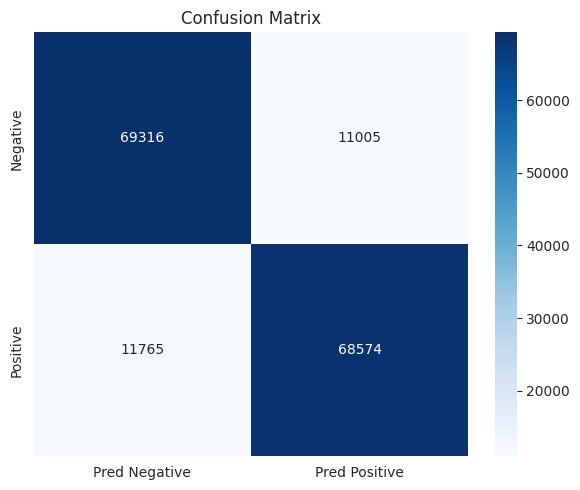

In [25]:
# =========================
# 26) CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm, index=["Negative", "Positive"], columns=["Pred Negative", "Pred Positive"])
display(cm_df)
cm_df.to_csv(f"{OUTPUT_DIR}/confusion_matrix.csv")

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png", dpi=300)
plt.show()

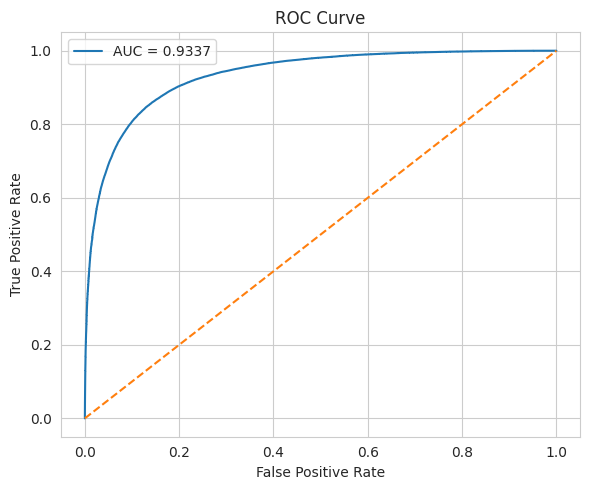

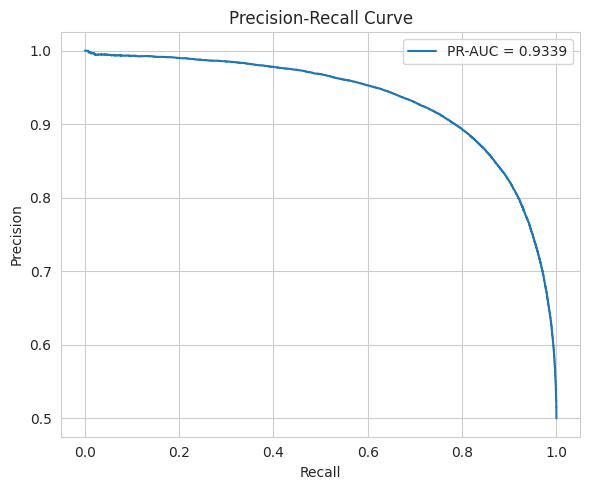

In [26]:
# =========================
# 27) ROC + PR CURVES
# =========================
fpr, tpr, _ = roc_curve(y_true, y_prob)
precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_true, y_prob):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/roc_curve.png", dpi=300)
plt.show()

plt.figure(figsize=(6, 5))
plt.plot(recall_curve, precision_curve, label=f"PR-AUC = {average_precision_score(y_true, y_prob):.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/pr_curve.png", dpi=300)
plt.show()

In [27]:
# =========================
# 28) PER-LANGUAGE / PER-SOURCE EVALUATION
# =========================
test_meta = test_ds.to_pandas().reset_index(drop=True)
test_meta["y_true"] = y_true
test_meta["y_pred"] = y_pred
test_meta["y_prob"] = y_prob

def eval_subset(df, name):
    if len(df) == 0:
        return None
    p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(
        df["y_true"], df["y_pred"], average="macro", zero_division=0
    )
    _, _, f_weighted, _ = precision_recall_fscore_support(
        df["y_true"], df["y_pred"], average="weighted", zero_division=0
    )
    return {
        "subset": name,
        "rows": len(df),
        "accuracy": accuracy_score(df["y_true"], df["y_pred"]),
        "precision_macro": p_macro,
        "recall_macro": r_macro,
        "f1_macro": f_macro,
        "f1_weighted": f_weighted,
        "roc_auc": roc_auc_score(df["y_true"], df["y_prob"]) if df["y_true"].nunique() == 2 else np.nan,
        "pr_auc": average_precision_score(df["y_true"], df["y_prob"]) if df["y_true"].nunique() == 2 else np.nan,
        "mcc": matthews_corrcoef(df["y_true"], df["y_pred"])
    }

lang_metrics = []
for lang in sorted(test_meta["lang"].unique()):
    lang_metrics.append(eval_subset(test_meta[test_meta["lang"] == lang], f"lang_{lang}"))

lang_metrics_df = pd.DataFrame(lang_metrics)
display(lang_metrics_df)
lang_metrics_df.to_csv(f"{OUTPUT_DIR}/per_language_metrics.csv", index=False)

source_metrics = []
for source in sorted(test_meta["source"].unique()):
    source_metrics.append(eval_subset(test_meta[test_meta["source"] == source], f"source_{source}"))

source_metrics_df = pd.DataFrame(source_metrics)
display(source_metrics_df)
source_metrics_df.to_csv(f"{OUTPUT_DIR}/per_source_metrics.csv", index=False)

,subset,rows,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,roc_auc,pr_auc,mcc
0,lang_ar,941,0.591923,0.594464,0.591835,0.589027,0.589064,0.641736,0.672855,0.186281
1,lang_en,159719,0.859841,0.859867,0.859842,0.859839,0.859839,0.934489,0.934663,0.719709


,subset,rows,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,roc_auc,pr_auc,mcc
0,source_LABR,941,0.591923,0.594464,0.591835,0.589027,0.589064,0.641736,0.672855,0.186281
1,source_Sentiment140,159719,0.859841,0.859867,0.859842,0.859839,0.859839,0.934489,0.934663,0.719709


,text,labels,lang,source,y_true,y_pred,y_prob,error_type
9,?...still looking.,0,en,Sentiment140,0,1,0.524378,False Positive
19,no1 wished me a happy mothers day,0,en,Sentiment140,0,1,0.946108,False Positive
21,gotta love lazy days although i am kinda lonel...,1,en,Sentiment140,1,0,0.318050,False Negative
26,i'll see you guys tomorrow. i miss kamu!,1,en,Sentiment140,1,0,0.144433,False Negative
43,لم يعجبني هذا الكتاب . لقد ضعت بين السرد الروا...,1,ar,LABR,1,0,0.117879,False Negative
53,having a night in with a take away and gossip ...,0,en,Sentiment140,0,1,0.997551,False Positive
61,#tonys ...and evidently they canceled each oth...,0,en,Sentiment140,0,1,0.577885,False Positive
64,no but email them i will go to the library later,0,en,Sentiment140,0,1,0.874573,False Positive
65,- looks like someone needs to throw another 1t...,1,en,Sentiment140,1,0,0.179776,False Negative
69,going to attempt a bath in the apt. tub i woul...,0,en,Sentiment140,0,1,0.606851,False Positive


,error_type,count
0,Correct,137890
1,False Negative,11765
2,False Positive,11005


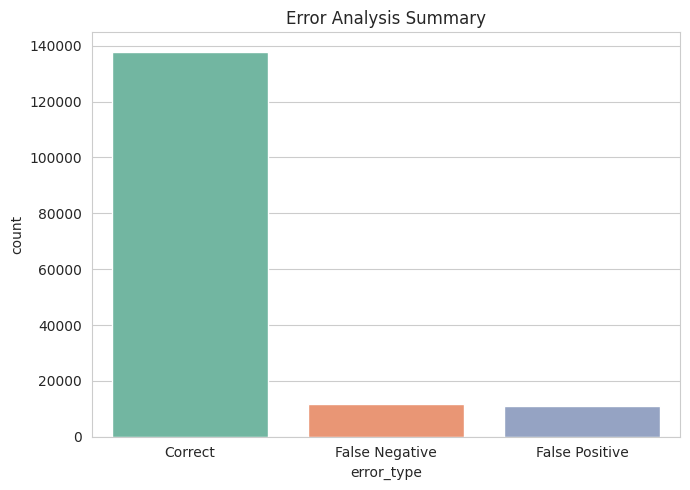

In [28]:
# =========================
# 29) ERROR ANALYSIS
# =========================
test_texts = test_ds.to_pandas()["text"].reset_index(drop=True)

errors_df = test_meta.copy()
errors_df["text"] = test_texts
errors_df["error_type"] = np.where(
    (errors_df["y_true"] == 0) & (errors_df["y_pred"] == 1),
    "False Positive",
    np.where(
        (errors_df["y_true"] == 1) & (errors_df["y_pred"] == 0),
        "False Negative",
        "Correct"
    )
)

error_examples = errors_df[errors_df["error_type"] != "Correct"].copy()
display(error_examples.head(20))
error_examples.to_csv(f"{OUTPUT_DIR}/error_examples.csv", index=False)

error_summary = errors_df["error_type"].value_counts().reset_index()
error_summary.columns = ["error_type", "count"]
display(error_summary)
error_summary.to_csv(f"{OUTPUT_DIR}/error_summary.csv", index=False)

plt.figure(figsize=(7, 5))
sns.barplot(data=error_summary, x="error_type", y="count", palette="Set2")
plt.title("Error Analysis Summary")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/error_summary_barplot.png", dpi=300)
plt.show()

In [29]:
# =========================
# 30) FINAL PIPELINE TEST
# =========================
clf = pipeline(
    "text-classification",
    model=MODEL_SAVE_DIR,
    tokenizer=MODEL_SAVE_DIR,
    top_k=None
)

print(clf("I love this movie!"))
print(clf("هذه الرواية مملة جدا"))
print(clf("التقرير الاقتصادي يبدو متفائلاً هذا العام"))

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


[[{'label': 'LABEL_1', 'score': 0.9982166886329651}, {'label': 'LABEL_0', 'score': 0.0017832262674346566}]]
[[{'label': 'LABEL_0', 'score': 0.902088463306427}, {'label': 'LABEL_1', 'score': 0.0979115292429924}]]
[[{'label': 'LABEL_0', 'score': 0.9177560806274414}, {'label': 'LABEL_1', 'score': 0.0822438970208168}]]


In [30]:
# =========================
# 31) THESIS TABLES
# =========================
dataset_summary_table = pd.DataFrame([
    {
        "Dataset": "LABR",
        "Original size": labr_original_size,
        "Final size after cleaning": len(df_ar),
        "Labels used": "Binary",
        "Language": "Arabic",
        "Role": "Train/Val/Test"
    },
    {
        "Dataset": "Sentiment140",
        "Original size": len(df_en_raw),
        "Final size after cleaning": len(df_en),
        "Labels used": "Binary",
        "Language": "English",
        "Role": "Train/Val/Test"
    }
])
dataset_summary_table.to_csv(f"{OUTPUT_DIR}/table_A_dataset_summary.csv", index=False)

split_table = split_df_summary.copy()
split_table.to_csv(f"{OUTPUT_DIR}/table_B_split_summary.csv", index=False)

text_length_table = token_length_summary[["dataset", "mean_tokens", "median_tokens", "p95_tokens", "p99_tokens", "pct_le_max_length"]].copy()
text_length_table.columns = ["Dataset", "Mean tokens", "Median tokens", "95th percentile", "99th percentile", "Percent <= max_length"]
text_length_table.to_csv(f"{OUTPUT_DIR}/table_C_text_length_summary.csv", index=False)

main_eval_table = global_metrics_df.copy()
main_eval_table.to_csv(f"{OUTPUT_DIR}/table_D_main_evaluation_metrics.csv", index=False)

lang_metrics_df.to_csv(f"{OUTPUT_DIR}/table_E_per_language_performance.csv", index=False)

error_table = pd.DataFrame([{
    "False positives count": int((errors_df["error_type"] == "False Positive").sum()),
    "False negatives count": int((errors_df["error_type"] == "False Negative").sum()),
    "Total errors": int((errors_df["error_type"] != "Correct").sum())
}])
error_table.to_csv(f"{OUTPUT_DIR}/table_F_error_analysis_summary.csv", index=False)

thesis_summary = pd.DataFrame([{
    "model_name": MODEL_NAME,
    "max_length": MAX_LENGTH,
    "learning_rate": 2e-5,
    "train_batch_size": 16,
    "eval_batch_size": 32,
    "epochs": 3,
    "weight_decay": 0.01,
    "train_en_used": len(train_en),
    "train_ar_used": len(train_ar),
    "val_total": len(val_ds),
    "test_total": len(test_ds)
}])
display(thesis_summary)
thesis_summary.to_csv(f"{OUTPUT_DIR}/thesis_training_setup.csv", index=False)

,model_name,max_length,learning_rate,train_batch_size,eval_batch_size,epochs,weight_decay,train_en_used,train_ar_used,val_total,test_total
0,xlm-roberta-base,128,0.00002,16,32,3,0.01,200000,7526,160660,160660


In [31]:
# =========================
# 32) ZIP OUTPUTS
# =========================
import shutil

archive_base = "/kaggle/working/xlmr_finetune_artifacts"
shutil.make_archive(archive_base, "zip", OUTPUT_DIR)

print("Artifacts zip:", archive_base + ".zip")
print("Model folder:", MODEL_SAVE_DIR)

Artifacts zip: /kaggle/working/xlmr_finetune_artifacts.zip
Model folder: /kaggle/working/xlmr_multilingual_sentiment_best


In [32]:
# =========================
# 33) GENERATED FILES SUMMARY
# =========================
all_files = []
for root, dirs, files in os.walk(OUTPUT_DIR):
    for file in files:
        all_files.append(os.path.join(root, file))

summary_files_df = pd.DataFrame({"file": all_files})
display(summary_files_df.head(50))
summary_files_df.to_csv(f"{OUTPUT_DIR}/generated_files_list.csv", index=False)

print("DONE.")

,file
0,/kaggle/working/xlmr_labr_sent140_outputs/samp...
1,/kaggle/working/xlmr_labr_sent140_outputs/tabl...
2,/kaggle/working/xlmr_labr_sent140_outputs/trai...
3,/kaggle/working/xlmr_labr_sent140_outputs/toke...
4,/kaggle/working/xlmr_labr_sent140_outputs/per_...
5,/kaggle/working/xlmr_labr_sent140_outputs/labr...
6,/kaggle/working/xlmr_labr_sent140_outputs/top_...
7,/kaggle/working/xlmr_labr_sent140_outputs/post...
8,/kaggle/working/xlmr_labr_sent140_outputs/val_...
9,/kaggle/working/xlmr_labr_sent140_outputs/raw_...


DONE.


In [33]:
# =========================
# 34) CREATE FINAL ZIP FOR DOWNLOAD
# =========================
import shutil, os

if os.path.exists(OUTPUT_DIR):
    # ZIP الـ outputs
    shutil.make_archive("/kaggle/working/ALL_OUTPUTS", "zip", OUTPUT_DIR)
    size_mb = os.path.getsize("/kaggle/working/ALL_OUTPUTS.zip") / (1024 * 1024)
    print(f"✅ ALL_OUTPUTS.zip ready ({size_mb:.1f} MB)")
    
    # ZIP النموذج أيضاً
    if os.path.exists(MODEL_SAVE_DIR):
        shutil.make_archive("/kaggle/working/MODEL", "zip", MODEL_SAVE_DIR)
        model_mb = os.path.getsize("/kaggle/working/MODEL.zip") / (1024 * 1024)
        print(f"✅ MODEL.zip ready ({model_mb:.1f} MB)")
    
    print("\n📥 Go to Output panel → click Refresh 🔄 → Download")
else:
    print("⚠️ OUTPUT_DIR not found")

✅ ALL_OUTPUTS.zip ready (3059.3 MB)
✅ MODEL.zip ready (791.2 MB)

📥 Go to Output panel → click Refresh 🔄 → Download
